**Neonatal Jaundice Detection (NJN) — Stacking Ensemble V1**

In [1]:
!pip -q install opencv-python numpy pandas matplotlib scikit-learn scipy tqdm

import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Seed + Dataset Path + Load + Labeling**

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)

sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts (0,1):", np.bincount([l for _,l in pairs]))
print("Example:", pairs[:3])

Total labeled: 760
Class counts (0,1): [560 200]
Example: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


**ROI functions (FH/CH/AB)**

In [5]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.10*h); y2 = int(0.40*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.40*h); y2 = int(0.80*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.60*h); y2 = int(0.92*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

**Preprocess + Skin mask + Feature extraction**

In [6]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    return {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }

**Build aligned dataset (FH/CH/AB features in one DF)**

In [7]:
rows = []
failed = 0

for p, label in tqdm(pairs, desc="Extracting FH/CH/AB features"):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)

    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    fh_feat = extract_features_from_roi(fh)
    ch_feat = extract_features_from_roi(ch)
    ab_feat = extract_features_from_roi(ab)

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k,v in fh_feat.items()})
    row.update({f"CH_{k}": v for k,v in ch_feat.items()})
    row.update({f"AB_{k}": v for k,v in ab_feat.items()})
    rows.append(row)

df_all = pd.DataFrame(rows)
print("df_all shape:", df_all.shape, "Failed:", failed)
print(df_all["label"].value_counts())
df_all.head()

Extracting FH/CH/AB features: 100%|██████████| 760/760 [11:59<00:00,  1.06it/s]

df_all shape: (760, 77) Failed: 0
label
0    560
1    200
Name: count, dtype: int64


,path,label,FH_R_mean,FH_G_mean,FH_B_mean,FH_R_std,FH_G_std,FH_B_std,FH_R_p90,FH_G_p90,...,AB_H_mean,AB_S_mean,AB_V_mean,AB_V_std,AB_Hue_peak_bin,AB_L_mean,AB_a_mean,AB_Lab_b_mean,AB_Lab_b_p90,AB_yellow_prop
0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,133.808548,106.088112,92.571533,52.520000,42.079220,37.916626,200.599609,158.0,...,14.977246,54.757210,117.766083,28.167379,1.0,115.199997,130.831497,136.438614,140.0,0.229696
1,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,130.173294,111.093147,81.729721,49.389671,46.311573,44.033504,200.000000,180.0,...,11.253705,96.580063,151.865494,38.708691,1.0,133.264435,138.909378,144.334549,154.0,0.230641
2,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,122.268097,105.070572,94.897881,43.281628,46.512608,48.098530,176.000000,163.0,...,7.325994,75.608063,128.315277,45.169415,0.0,113.481529,138.528198,135.857864,140.0,0.212285
3,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,162.759598,142.262207,135.962982,39.922077,40.304707,40.055599,206.000000,186.0,...,7.552149,52.880051,177.885681,42.817516,0.0,163.562134,137.114136,135.620560,145.0,0.204689
4,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,110.031204,97.617279,92.540947,22.600916,21.307449,22.047573,137.000000,124.0,...,20.381281,40.961773,87.058746,31.533703,2.0,89.306404,128.047729,133.569687,135.0,0.150108


**Prepare region matrices + impute**

In [8]:
y = df_all["label"].astype(int).values

def get_region(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix+"_")]
    return df[cols].copy()

X_fh = get_region(df_all, "FH")
X_ch = get_region(df_all, "CH")
X_ab = get_region(df_all, "AB")

imp_fh = SimpleImputer(strategy="median")
imp_ch = SimpleImputer(strategy="median")
imp_ab = SimpleImputer(strategy="median")

X_fh = imp_fh.fit_transform(X_fh)
X_ch = imp_ch.fit_transform(X_ch)
X_ab = imp_ab.fit_transform(X_ab)

print(X_fh.shape, X_ch.shape, X_ab.shape)

(760, 25) (760, 25) (760, 25)


**Base models: OOF probabilities (leakage-free)**

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def oof_prob(X, y):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])
    prob = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:,1]
    return prob

prob_fh_oof = oof_prob(X_fh, y)
prob_ch_oof = oof_prob(X_ch, y)
prob_ab_oof = oof_prob(X_ab, y)

stack_X = np.vstack([prob_fh_oof, prob_ch_oof, prob_ab_oof]).T
print("Meta-feature shape:", stack_X.shape)

Meta-feature shape: (760, 3)


**Meta learner (Logistic Regression) — OOF AUC estimate**

In [10]:
meta = LogisticRegression(max_iter=2000)

prob_meta_oof = cross_val_predict(meta, stack_X, y, cv=cv, method="predict_proba")[:,1]
print("Stacking OOF AUC:", roc_auc_score(y, prob_meta_oof))

Stacking OOF AUC: 0.7759107142857143


**Final train/test evaluation + ROC/AUC + PR curve**

=== Stacking Test Report (thr=0.5) ===
              precision    recall  f1-score   support

           0      0.803     0.946     0.869       112
           1      0.700     0.350     0.467        40

    accuracy                          0.789       152
   macro avg      0.752     0.648     0.668       152
weighted avg      0.776     0.789     0.763       152

Confusion Matrix:
 [[106   6]
 [ 26  14]]
Stacking Test AUC: 0.784375


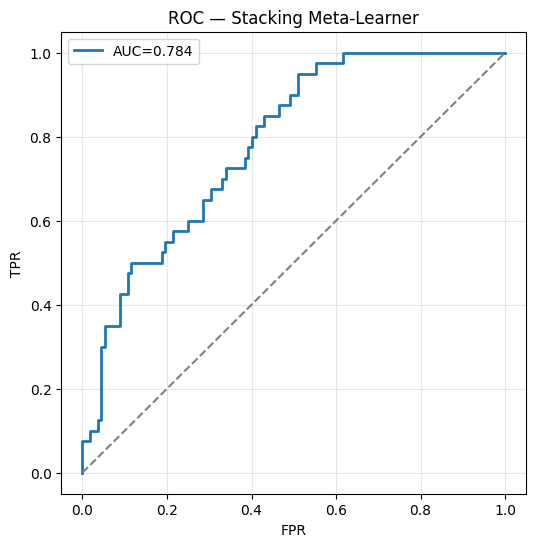

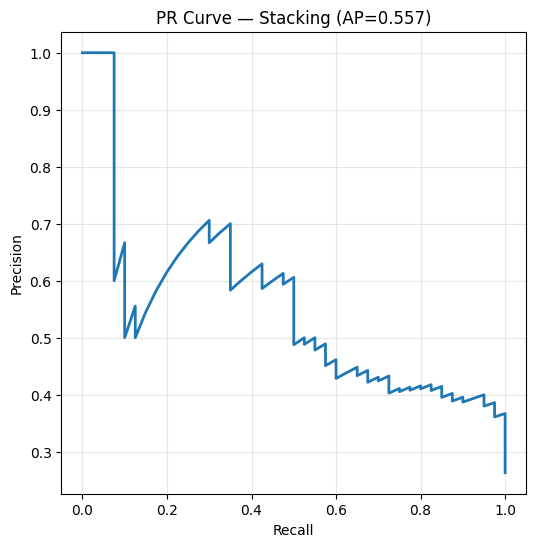

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    stack_X, y, test_size=0.2, random_state=42, stratify=y
)

meta.fit(X_train, y_train)
prob = meta.predict_proba(X_test)[:,1]
pred = (prob >= 0.5).astype(int)

print("=== Stacking Test Report (thr=0.5) ===")
print(classification_report(y_test, pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, thr = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("Stacking Test AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC — Stacking Meta-Learner")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

prec, rec, _ = precision_recall_curve(y_test, prob)
ap = average_precision_score(y_test, prob)
plt.figure(figsize=(6,6))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"PR Curve — Stacking (AP={ap:.3f})")
plt.grid(alpha=0.3)
plt.show()

**Threshold tuning (Youden J) + final confusion matrix**

In [12]:
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thr[best_idx]

print("Best Threshold (Youden J):", best_thr)
print("At Youden -> FPR:", fpr[best_idx], "TPR(Recall):", tpr[best_idx])

pred_y = (prob >= best_thr).astype(int)
print("\n=== Report @ Youden Threshold (Stacking) ===")
print(classification_report(y_test, pred_y, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_y))

Best Threshold (Youden J): 0.13609796753099143
At Youden -> FPR: 0.5089285714285714 TPR(Recall): 0.95

=== Report @ Youden Threshold (Stacking) ===
              precision    recall  f1-score   support

           0      0.965     0.491     0.651       112
           1      0.400     0.950     0.563        40

    accuracy                          0.612       152
   macro avg      0.682     0.721     0.607       152
weighted avg      0.816     0.612     0.628       152

Confusion Matrix:
 [[55 57]
 [ 2 38]]


**Calibration + Brier score (Stacking)**

Stacking Brier Score: 0.1582589888623111


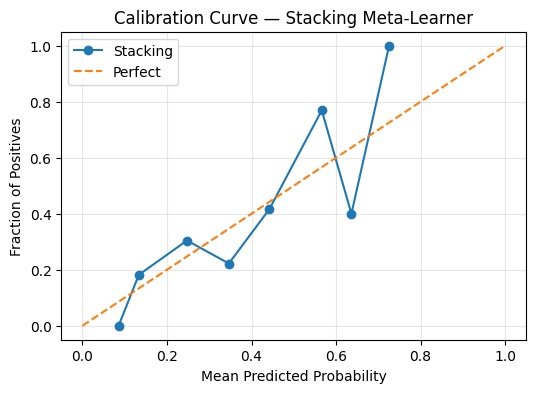

In [14]:
brier = brier_score_loss(y_test, prob)
print("Stacking Brier Score:", brier)

frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)

plt.figure(figsize=(6,4))
plt.plot(mean_pred, frac_pos, "o-", label="Stacking")
plt.plot([0,1],[0,1],"--", label="Perfect")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Stacking Meta-Learner")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretability: Meta weights (FH vs CH vs AB contribution)**

In [15]:
print("Meta weights [FH, CH, AB]:", meta.coef_[0])

Meta weights [FH, CH, AB]: [1.57960076 1.96876477 3.2222957 ]


Stacking of region-wise classical models did not improve beyond late fusion (AUC 0.784 vs 0.802), suggesting that region-level classical predictors are highly correlated; incorporating deep embeddings in the hybrid fusion was necessary for substantial gains.

**Final ablation table (add stacking row)**

| Model                    | Test AUC | Threshold | Recall(1) |   FPR | Accuracy | Confusion         |
| ------------------------ | -------: | --------: | --------: | ----: | -------: | ----------------- |
| Stacking (meta, thr=0.5) |    0.784 |      0.50 |      0.35 | 0.054 |    0.789 | [[106,6],[26,14]] |
| Stacking (meta, Youden)  |    0.784 |     0.136 |      0.95 | 0.509 |    0.612 | [[55,57],[2,38]]  |
